In [14]:
!pip install google_play_scraper

In [15]:
from google_play_scraper import app
import pandas as pd
import numpy as np

In [16]:
from google_play_scraper import reviews, Sort

result, continuation_token = reviews(
    'com.dts.freefiremax',
    lang='id',
    country='id',
    sort=Sort.NEWEST,   # pakai Sort, bukan sort
    count=2000,
    filter_score_with=None
)


In [17]:
df_busu = pd.DataFrame(np.array(result),columns=['review'])
df_busu = df_busu.join(pd.DataFrame(df_busu.pop('review').tolist()))
df_busu.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,422945d2-f8e5-43f2-a882-fc4d4b21a8d9,Rioo Shinigami05,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa ngebug woyyyy,5,0,2.118.1,2025-10-29 04:50:51,None,None,2.118.1
1,209e1a0c-4d71-48c0-8a71-00b82b4e3025,Fadli,https://play-lh.googleusercontent.com/a/ACg8oc...,Punya ku gak bisa buat loging soalnya uji coba...,5,0,2.115.1,2025-10-29 04:50:39,None,None,2.115.1
2,389d8e7b-45ce-478b-a8dd-cabf0aa8f353,Dinoii Dinoii,https://play-lh.googleusercontent.com/a/ACg8oc...,Tah lah,5,0,None,2025-10-29 04:50:37,None,None,None
3,284364f1-df15-4cd8-9fc1-b1b7ed8fa6bb,Perdi Puji Lukito,https://play-lh.googleusercontent.com/a/ACg8oc...,woyyy... udah ku instal... login pun masih ngg...,1,0,None,2025-10-29 04:50:35,None,None,None
4,05b26425-5885-4e30-b443-2d6b248ddc8e,Adzillah Mu'min,https://play-lh.googleusercontent.com/a/ACg8oc...,"game nya sangat wow, dan grafiknya wow , rank ...",5,0,None,2025-10-29 04:50:30,None,None,None


In [18]:
len(df_busu.index)

2000

In [19]:
df_busu[['userName', 'score', 'at', 'content']].head()

,userName,score,at,content
0,Rioo Shinigami05,5,2025-10-29 04:50:51,kenapa ngebug woyyyy
1,Fadli,5,2025-10-29 04:50:39,Punya ku gak bisa buat loging soalnya uji coba...
2,Dinoii Dinoii,5,2025-10-29 04:50:37,Tah lah
3,Perdi Puji Lukito,1,2025-10-29 04:50:35,woyyy... udah ku instal... login pun masih ngg...
4,Adzillah Mu'min,5,2025-10-29 04:50:30,"game nya sangat wow, dan grafiknya wow , rank ..."


In [20]:
my_df = df_busu[['userName', 'score', 'at', 'content']]

In [21]:
my_df.to_csv("hasil_scraping_data.csv", index = False)

CASE FOLDING

In [22]:
import pandas as pd

# Baca file CSV
df = pd.read_csv("hasil_scraping_data.csv")

# Tampilkan kolom yang ada
print("Kolom tersedia:", df.columns)

# Misalnya kolom review ada di 'content', lakukan case folding
df['content_casefold'] = df['content'].astype(str).str.lower()

# Simpan hasilnya ke file baru
output_path = "hasil_casefold.csv"
df.to_csv(output_path, index=False)

print(f"Case folding selesai. File hasil disimpan di {output_path}")

Kolom tersedia: Index(['userName', 'score', 'at', 'content'], dtype='object')
Case folding selesai. File hasil disimpan di hasil_casefold.csv


PREPROCESSING DATA

In [23]:
pip install Sastrawi

NORMALISASI KATA, REMOVE DUPLIKAT, + BI-GRAM, TRI-GRAM, DAN WORDCLOUD

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


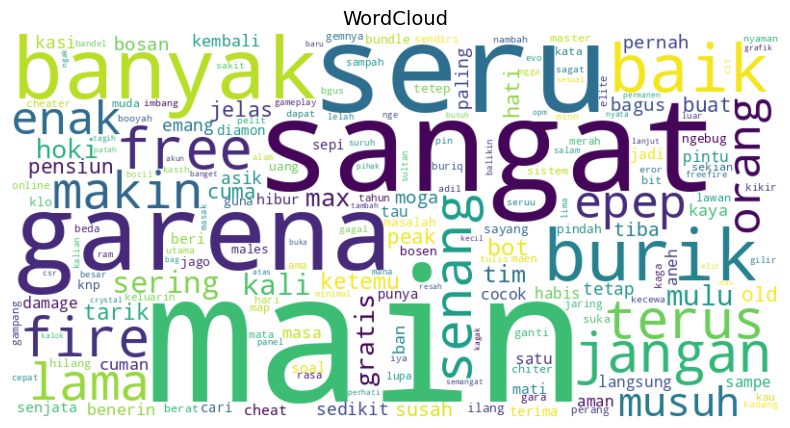

✅ Preprocessing selesai! File disimpan sebagai 'hasil_final.csv'


In [30]:
import pandas as pd
import re
import nltk
from collections import OrderedDict
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Unduh resource NLTK
nltk.download('punkt')
nltk.download('punkt_tab')

# ===============================
# 1. Baca Data
# ===============================
df = pd.read_csv('hasil_casefold.csv')

if 'content_casefold' not in df.columns:
    raise ValueError("Kolom 'content_casefold' tidak ditemukan di file CSV kamu.")

reviews = df['content_casefold']

# ===============================
# 2. Cleansing (hapus simbol, angka, tanda baca)
# ===============================
def clean_text(text):
    text = re.sub(r'[^a-z\s]', '', str(text))  # hanya huruf kecil dan spasi
    text = re.sub(r'\s+', ' ', text).strip()   # hapus spasi berlebih
    return text

df['cleaned'] = reviews.apply(clean_text)

# ===============================
# 3. Normalisasi Kata
# ===============================
normalisasi_dict = {
    # kata gaul → kata baku
    "ngeleg": "lemot", "ngelag": "lemot", "leg": "lemot", "lag": "lemot","gamenya": "game nya",
    "geme": "permainan", "game": "permainan", "gem": "permainan", "boyah": "booyah",
    "asikm": "asik", "asyik": "asik", "cape": "lelah", "capek": "lelah",
    "hoky": "beruntung", "susa": "sulit", "duit": "uang", "pensi": "pensiun",
    "enkk": "enak", "enakkk": "enak", "baget": "banget", "bgt": "banget", "bgtt": "banget",
    "gajelas": "tidak jelas", "gajelas": "tidak jelas", "gkjelas": "tidak jelas",
    "abis": "habis", "dikit": "sedikit", "gabisa": "tidak bisa", "gbs": "tidak bisa",
    "bgs": "bagus", "bgtu": "begitu", "dm": "berlian", "blm": "belum", "br": "baru",
    "bwt": "buat", "dah": "sudah", "udh": "sudah", "uda": "sudah", "sdh": "sudah",
    "lemottt": "lemot", "mantapp": "mantap", "mantappu": "mantap", "moga": "semoga",
    "msh": "masih", "nyesel": "menyesal", "nyari": "mencari", "nyampe": "sampai",
    "parahh": "parah", "pny": "punya", "skrg": "sekarang", "sm": "sama",
    "smpe": "sampai", "bener": "benar", "beneran": "benar", "tdk": "tidak",
    "tq": "terima kasih", "makasi": "terima kasih", "makasii": "terima kasih",
    "makasiii": "terima kasih", "thx": "terima kasih", "thankyou": "terima kasih",
    "plis": "tolong", "please": "tolong", "pliss": "tolong",
    "okey": "oke", "okayy": "oke", "sippp": "sip", "sipppp": "sip",
    "bener2": "benar-benar", "bgt2": "banget-banget", "parah2": "sangat parah"
}


def normalisasi_kata(text):
    words = str(text).split()
    normalized = [normalisasi_dict.get(word, word) for word in words]
    return ' '.join(normalized)

df['normalized'] = df['cleaned'].apply(normalisasi_kata)

# ===============================
# 4. Tokenisasi
# ===============================
df['tokens'] = df['normalized'].apply(word_tokenize)

# ===============================
# 5. Stopword Removal
# ===============================
stop_factory = StopWordRemoverFactory()
stopwords_sastrawi = set(stop_factory.get_stop_words())

custom_stopwords = {
    #  kata umum pengisi kalimat
    'aja','ajg','amat','bang','banget','biar','boleh','deh','dong','doang','gitu','gimana',
    'gua','gue','huh','jadi','yaaa','ya','yah','kan','lah','loh','kok','kek','nih','no',
    'kayak','kayanya','malah','mau','yaa','yaah','nih','tuh','lah','loh','deh','dong','sih',

    #  kata perasaan / ekspresif
    'asli','parah','anjir','anjay','anjayy','anjg','asu','wow','wkwk','wkwkwk',
    'haha','hahaha','hehe','hehehe','hadeh','ckck','ckckk','ckckkk','huhh',
    'anj','anjg','anjay','anjir','tolol','bodoh','mantap','mantapp','mantappp','mantapppp',

    #  kata sapaan / umum di review
    'aku','kamu','anda','lu','elo','bro','sis','guys','teman','temen','sob','sobat','min','mimin',

    #  konjungsi / penghubung
    'dan','atau','tapi','padahal','namun','jadi','karena','sebab','biarpun',
    'walaupun','meskipun','kalau','kalo','pas','saat','ketika','agar','supaya','meski',
    'karna','biar','supaya','meskipun','walau','agar','sehingga','bagi','oleh','serta','dalam',

    #  kata waktu / tempat umum
    'dimana','disini','disana','kesini','kesana','situ','sini','itu','ini','udah','udahh','udahhh',
    'dulu','sekarang','selalu','waktu','setiap','akhir','akhirnya','lagi','baru',

    #  kata tidak bermakna tinggi
    'apa','apaan','apaja','ngapa','kenapa','mengapa','yaudah','lagi','lagii','lagiii','sih','yaampun',
    'semua','setiapnya','pokoknya','intinya','kayanya','kayak','begitu','gitu','gini','pokoknya','macem','macam',

    #  singkatan / gaul
    'gk','gak','ga','nggak','tdk','enggak','btw','pls','plis','please',
    'bt','bngt','tp','tpi','sm','aja','doang','dong','bgtu','dr','jd','trs','trus',
    'ok','oke','okey','okay','okayy','okeyy','okeyyy','sip','pliss','plisss','plzzz','thx','thank','thanks','thankyou',

    #  sosial / ucapan
    'makasih','terimakasih','makasi','makasii','makasiii','thank','thanks','thankyou',
    'tolong','mohon','izin','permisi','maaf','sorry','sory','thx',

    #  kata penguat / tambahan
    'amat','sekali','banget','parah','mantap','mantapp','mantappp','best','baguss','bagusss',
    'oke','ok','okey','okayy','sip','good','nice','great','super','top','keren','hebat',
    'bgt','serius','bener','benar',

    #  kata umum di ulasan (opini biasa)
    'biasa','biasaaja','lumayan','cukup','bagus','baik','jelek','kurang','lebih','terlalu',
    'lemot','lancar','mantap','recommended','recomended','rekomendasi','bagusbanget',
    'booring','buruk','jelek','topmarkotop','suka','cinta','favorit','terbaik',

    #  kata teknis / konteks game
    'main','berlian','citer','spin','rank','bintang','skin','login','akun','diamond',
    'ranked','update','event','game','gamenya','player','server','wifi','data',
    'download','bug','lag','sinyal','jaring','jaringan','mode','match','fitur',
    'battle','royale','push','mabar','ml','ff','pubg','ranknya','akunmu','id',
    'dev','developer','admin','mode','season','rankednya','grafik','updatean','big',

    #  kata kerja umum (tidak memberi opini)
    'bikin','kasih','tarik','coba','kena','dapet','dapat','jadi','milih','beli','jual','tambah','hapus',
    'kalah','menang','rusak','minta','hilang','keluar','masuk','ambil','taruh','naik','turun','mulai',
    'pake','pakai','install','buka','tutup','jalan','balik','ambil','hapus','isi','pilih','ngisi','mainin',
    'ngulang','ulang','ngulangin','buat','sama','kasih','ben',

    #  kata ganti & bantu
    'saya','aku','kamu','lu','loe','gua','gw','dia','mereka','kami','kita',
    'mu','ku','nya','itu','ini','sini','situ','dimana','disitu','kesitu','pun','juga','ya','yah','woi','woy'
}


all_stopwords = stopwords_sastrawi.union(custom_stopwords)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in all_stopwords]

df['no_stopword'] = df['tokens'].apply(remove_stopwords)

# ===============================
# 6. Stemming
# ===============================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_text(tokens):
    return [stemmer.stem(t) for t in tokens]

df['stemmed'] = df['no_stopword'].apply(stemming_text)

# ===============================
# 7. Hapus Duplikat & Huruf Berulang
# ===============================
def remove_duplicates(tokens):
    unique_words = list(OrderedDict.fromkeys(tokens))
    return unique_words

def bersihkan_huruf_berulang(tokens):
    cleaned = []
    for w in tokens:
        w = re.sub(r'(.)\1{2,}', r'\1', w)
        if len(w) >= 3:
            cleaned.append(w)
    return cleaned

df['unique'] = df['stemmed'].apply(remove_duplicates)
df['clean_final'] = df['unique'].apply(bersihkan_huruf_berulang)

# ===============================
# 8. Gabungkan Kembali ke Kalimat
# ===============================
df['preprocessed'] = df['clean_final'].apply(lambda tokens: ' '.join(tokens))

# ===============================
# 9. Generate N-grams
# ===============================
def generate_ngrams(tokens, n):
    return list(ngrams(tokens, n))

df['Unigram'] = df['clean_final'].apply(lambda x: generate_ngrams(x, 1))
df['Bigram'] = df['clean_final'].apply(lambda x: generate_ngrams(x, 2))
df['Trigram'] = df['clean_final'].apply(lambda x: generate_ngrams(x, 3))

# ===============================
# 10. WordCloud
# ===============================
all_words = ' '.join(df['preprocessed'])
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud", fontsize=14)
plt.show()
wordcloud.to_file('wordcloud.png')

# ===============================
# 11. Simpan Hasil Akhir
# ===============================
df.to_csv('hasil_final.csv', index=False)
print("✅ Preprocessing selesai! File disimpan sebagai 'hasil_final.csv'")
